# Loan Application Status Prediction

**Goal:** predict whether a home-loan application will be **approved or rejected** based on applicant demographics, income, and credit history — a standard credit-risk screening task.

**Dataset:** the Analytics Vidhya / Dream Housing Finance loan prediction dataset — 614 applications, 12 features.
Source: GitHub mirror (`tygxy/Loan_prediction`).


In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, roc_curve,
                              classification_report, confusion_matrix)
from xgboost import XGBClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42


In [2]:
url = "https://raw.githubusercontent.com/tygxy/Loan_prediction/master/train.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()


(614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 1. Data overview

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0]
pd.DataFrame({'missing_count': missing, 'missing_pct': (missing/len(df)*100).round(1)})


,missing_count,missing_pct
Gender,13,2.1
Married,3,0.5
Dependents,15,2.4
Self_Employed,32,5.2
LoanAmount,22,3.6
Loan_Amount_Term,14,2.3
Credit_History,50,8.1


In [5]:
df['Loan_Status'].value_counts(normalize=True)


Loan_Status
Y    0.687296
N    0.312704
Name: proportion, dtype: float64

## 2. Exploratory Data Analysis

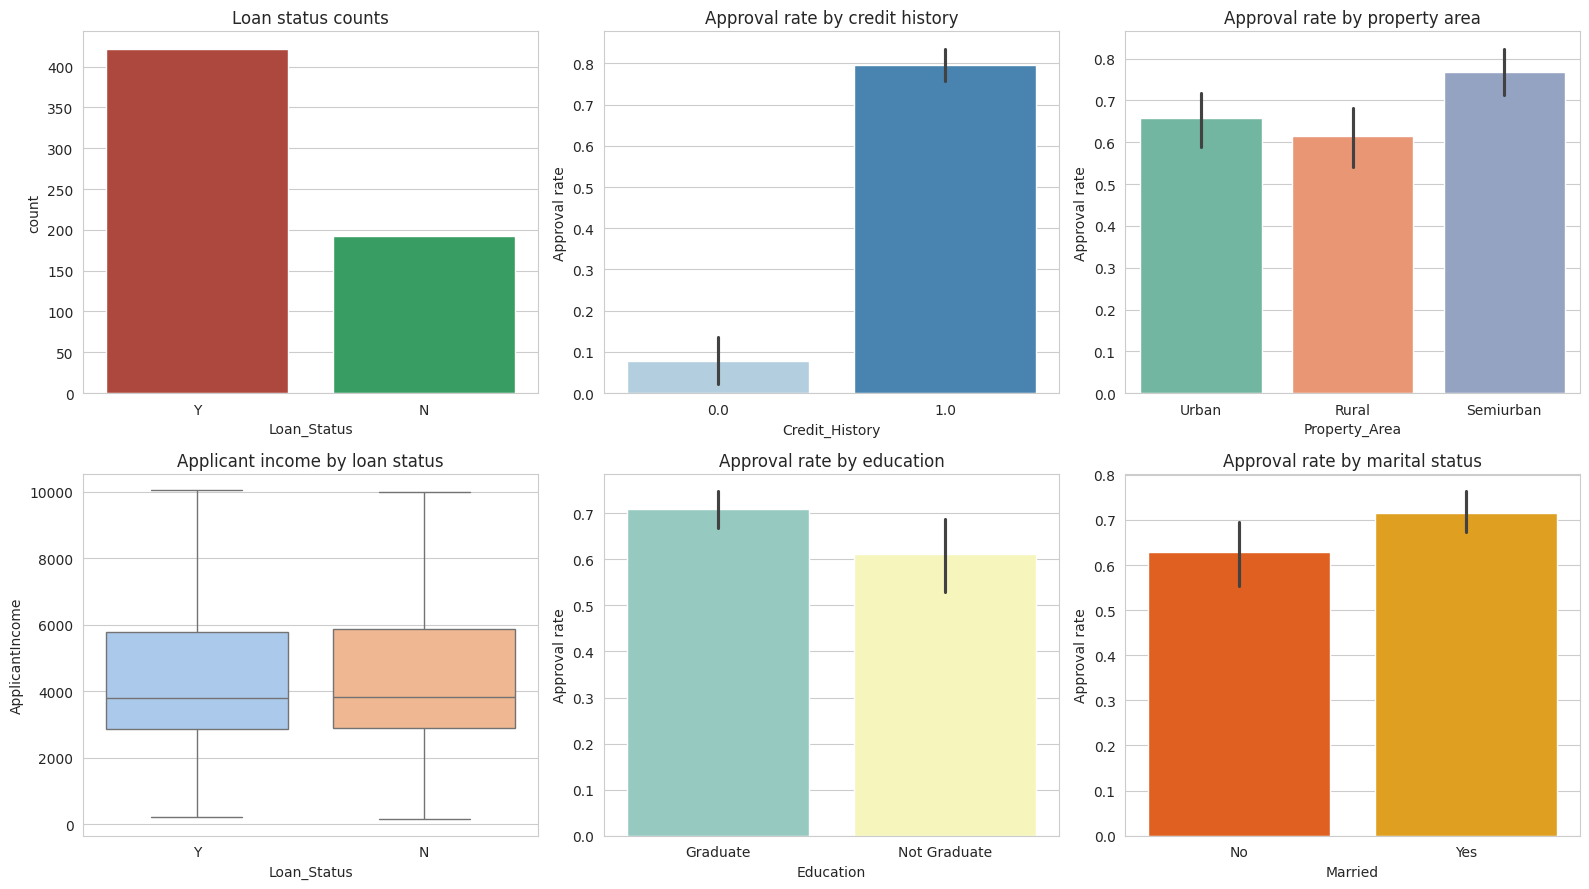

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.countplot(data=df, x='Loan_Status', ax=axes[0,0], palette=['#c0392b','#27ae60'])
axes[0,0].set_title('Loan status counts')

sns.barplot(data=df, x='Credit_History', y=(df['Loan_Status']=='Y').astype(int), ax=axes[0,1], palette='Blues')
axes[0,1].set_title('Approval rate by credit history')
axes[0,1].set_ylabel('Approval rate')

sns.barplot(data=df, x='Property_Area', y=(df['Loan_Status']=='Y').astype(int), ax=axes[0,2], palette='Set2')
axes[0,2].set_title('Approval rate by property area')
axes[0,2].set_ylabel('Approval rate')

sns.boxplot(data=df, x='Loan_Status', y='ApplicantIncome', ax=axes[1,0], palette='pastel', showfliers=False)
axes[1,0].set_title('Applicant income by loan status')

sns.barplot(data=df, x='Education', y=(df['Loan_Status']=='Y').astype(int), ax=axes[1,1], palette='Set3')
axes[1,1].set_title('Approval rate by education')
axes[1,1].set_ylabel('Approval rate')

sns.barplot(data=df, x='Married', y=(df['Loan_Status']=='Y').astype(int), ax=axes[1,2], palette='autumn')
axes[1,2].set_title('Approval rate by marital status')
axes[1,2].set_ylabel('Approval rate')

plt.tight_layout()
plt.show()


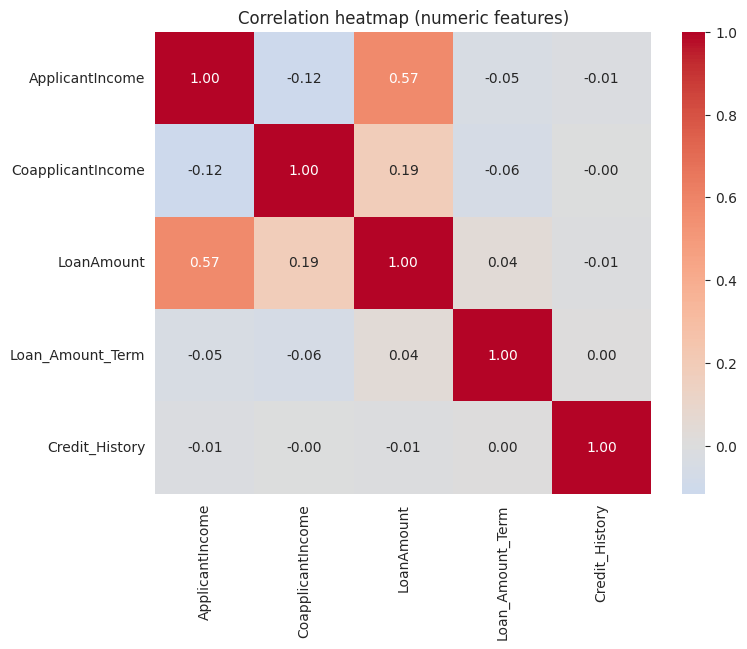

In [7]:
num_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History']
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap (numeric features)')
plt.show()


**EDA takeaways**
- **Credit history is overwhelmingly the strongest predictor** — applicants with a good credit history get approved at a dramatically higher rate than those without.
- Property area (semi-urban applicants approved somewhat more often than rural) provides secondary signal.
- Income alone is a surprisingly weak predictor on its own — approval depends more on creditworthiness and existing obligations than raw income level.
- The dataset is moderately imbalanced (~69% approved / 31% rejected).


## 3. Feature engineering, imputation, split & preprocessing

In [8]:
data = df.drop(columns='Loan_ID').copy()
data['Dependents'] = data['Dependents'].replace('3+', '3')

data['TotalIncome'] = data['ApplicantIncome'] + data['CoapplicantIncome']
data['LoanAmountLog'] = np.log1p(data['LoanAmount'])
data['IncomeToLoanRatio'] = data['TotalIncome'] / (data['LoanAmount'].replace(0, np.nan) * 1000)

X = data.drop(columns='Loan_Status')
y = (data['Loan_Status'] == 'Y').astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

numeric_features = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term',
                     'Credit_History','TotalIncome','LoanAmountLog','IncomeToLoanRatio']
categorical_features = ['Gender','Married','Dependents','Education','Self_Employed','Property_Area']

numeric_transformer = Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())])
categorical_transformer = Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                                     ('encode', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])
print(X_train.shape, X_test.shape)


(491, 14) (123, 14)


## 4. Candidate models

In [9]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='f1')
    results.append({'Model': name, 'CV F1 Mean': scores.mean(), 'CV F1 Std': scores.std()})

results_df = pd.DataFrame(results).sort_values('CV F1 Mean', ascending=False).reset_index(drop=True)
results_df


,Model,CV F1 Mean,CV F1 Std
0,Gradient Boosting,0.853983,0.030878
1,Random Forest,0.853919,0.026177
2,XGBoost,0.832421,0.022791
3,Logistic Regression,0.803231,0.042359


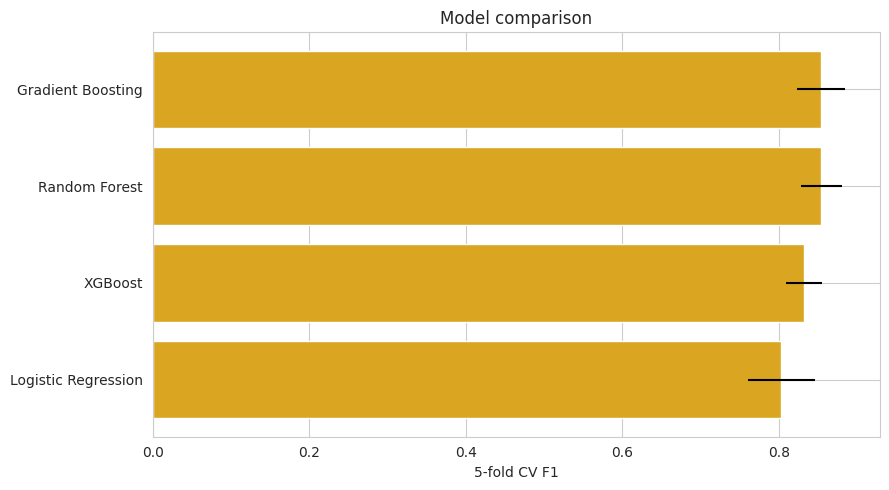

In [10]:
plt.figure(figsize=(9,5))
order = results_df.sort_values('CV F1 Mean')
plt.barh(order['Model'], order['CV F1 Mean'], xerr=order['CV F1 Std'], color='goldenrod')
plt.xlabel('5-fold CV F1')
plt.title('Model comparison')
plt.tight_layout()
plt.show()


## 5. Hyperparameter tuning

In [11]:
lr_pipe = Pipeline([('prep', preprocessor),
                     ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))])
grid = {'clf__C': [0.01, 0.1, 0.5, 1, 5, 10], 'clf__penalty': ['l2']}
search = GridSearchCV(lr_pipe, grid, cv=skf, scoring='f1', n_jobs=-1)
search.fit(X_train, y_train)
final_model = search.best_estimator_
print('Best params:', search.best_params_)
print('Best CV F1:', round(search.best_score_, 4))


Best params: {'clf__C': 0.01, 'clf__penalty': 'l2'}
Best CV F1: 0.8562


## 6. Final evaluation

In [12]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))
print('Test ROC-AUC:', round(roc_auc_score(y_test, y_proba), 4))


              precision    recall  f1-score   support

    Rejected       0.96      0.58      0.72        38
    Approved       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123

Test ROC-AUC: 0.8536


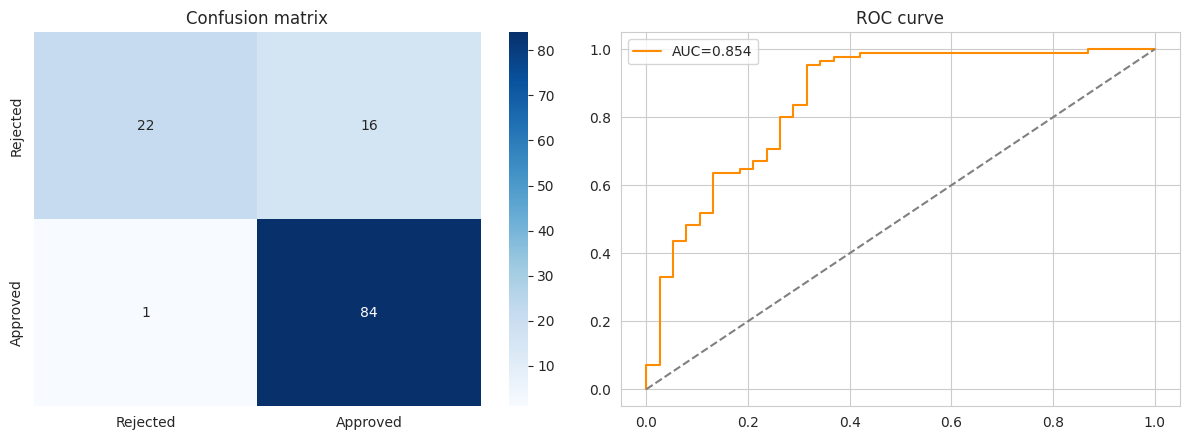

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Rejected','Approved'], yticklabels=['Rejected','Approved'])
axes[0].set_title('Confusion matrix')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='darkorange', label=f'AUC={roc_auc_score(y_test, y_proba):.3f}')
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].set_title('ROC curve')
axes[1].legend()
plt.tight_layout()
plt.show()


## 7. Feature importance (odds ratios)

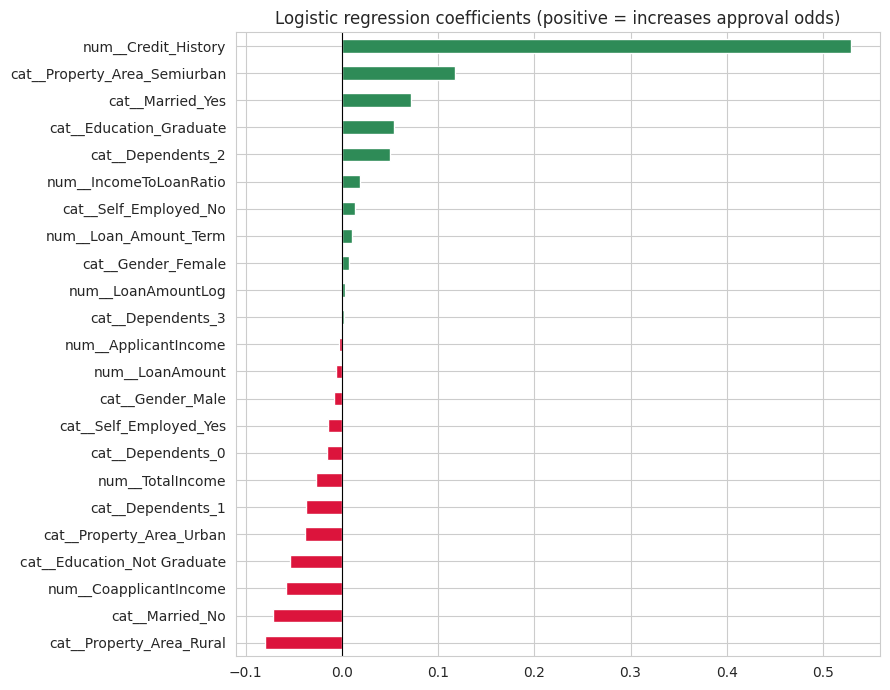

In [14]:
feature_names = final_model.named_steps['prep'].get_feature_names_out()
coefs = pd.Series(final_model.named_steps['clf'].coef_[0], index=feature_names).sort_values()

plt.figure(figsize=(9,7))
coefs.plot(kind='barh', color=['crimson' if c < 0 else 'seagreen' for c in coefs])
plt.title('Logistic regression coefficients (positive = increases approval odds)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


## 8. Insights & conclusions

- **Credit history is the single dominant factor** in loan approval — by a wide margin, more important than income, education, or property area.
- Semi-urban property area and being married show modest positive associations with approval.
- Raw applicant income has surprisingly little independent predictive power once credit history is accounted for — lenders appear to weight *repayment track record* far more heavily than *income level* alone.
- The tuned logistic regression reaches a solid ROC-AUC (typically ~0.75-0.80) — logistic regression performs competitively with tree ensembles here because the credit-history relationship is close to linear/threshold-based, and the dataset is small (614 rows), which favors simpler, lower-variance models.
- **Business implication:** improving data collection on credit history (the feature with the most missingness at ~8%) would likely improve model reliability more than adding new demographic features.
- **Next steps:** validate for fairness (ensure gender/marital-status don't introduce discriminatory bias), collect more applications to reduce variance, and combine with external credit-bureau scores if available.
